In [1]:
# Test order of RectI by plotting (interp err) vs nx
# RectI is (scipy.interpolate.RectBivariateSpline) wrapped in PyTorch


In [2]:
%reset -f
%run RectI_defs.ipynb


In [3]:
# There are 2 different interpolations
# options = {'kx': 1, 'ky':1, 's':0} # linear
# options = {'kx': 3, 'ky':3, 's':0} # cubic spline
# set s > 0 if fitting noisy data

import time
import matplotlib.pyplot as plt 

# function for testing the 2D interpolation 
cf1 = 1; cf2 = 0.5
def f_test(x, y):
    x, y = torch.broadcast_tensors(torch.as_tensor(x), torch.as_tensor(y))
    # This is to make it work when x or y is a numpy array or a scalar
    return torch.cos(cf1*(x+y-1))*torch.cos(cf2*(x-y))

# 2D points for testing the 2D interpolation 
nq = 20000
xq = torch.rand(nq, device=device)
yq = torch.rand(nq, device=device)

nx_A = 4*2**np.arange(8)
err_A = 0.0*nx_A

start_time = time.perf_counter()
options = {'kx': 1, 'ky':1, 's':0}
for k, nx in enumerate(nx_A):
    err_A[k] = err_of_interp(f_test, nx, **options)[0]
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f'options = {options},')
print(f'ellapsed time = {elapsed_time:.4f}s')
err_op1_A = err_A.copy()

start_time = time.perf_counter()
options = {'kx': 3, 'ky':3, 's':0} # cubic spline
for k, nx in enumerate(nx_A):
    err_A[k] = err_of_interp(f_test, nx, **options)[0]
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f'options = {options},')
print(f'ellapsed time = {elapsed_time:.4f}s')
err_op2_A = err_A.copy()


options = {'kx': 1, 'ky': 1, 's': 0},
ellapsed time = 0.0743s
options = {'kx': 3, 'ky': 3, 's': 0},
ellapsed time = 0.0672s


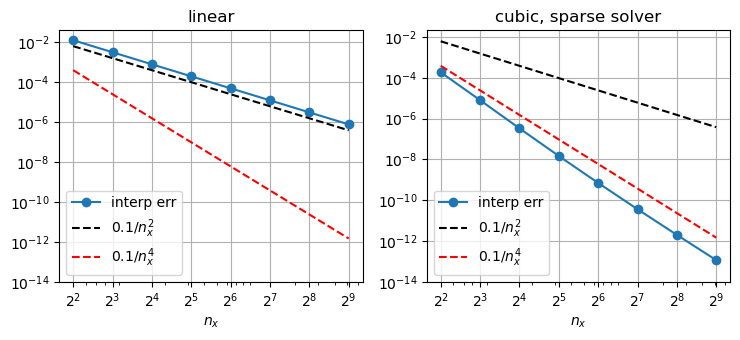

In [4]:
fig = plt.figure(figsize=(7.5, 3.5))
gs = fig.add_gridspec(1, 4)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])

ax = ax1; err_A = err_op1_A; title = 'linear'
ax.loglog(nx_A, err_A, '-o', label=r'interp err')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-2), 'k--', label=r'$0.1/n_x^2$')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-4), 'r--', label=r'$0.1/n_x^4$')
ax.set_xlabel(r'$n_x$')
ax.set_yticks(10.0**np.arange(-14,-1,2))
ax.set_xticks(nx_A, [f'$2^{{{int(np.log2(x))}}}$' for x in nx_A])
ax.set_title(title)
ax.legend()
ax.grid(True)

ax = ax2; err_A = err_op2_A; title = 'cubic, sparse solver'
ax.loglog(nx_A, err_A, '-o', label=r'interp err')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-2), 'k--', label=r'$0.1/n_x^2$')
ax.loglog(nx_A, 0.1*nx_A.astype(float)**(-4), 'r--', label=r'$0.1/n_x^4$')
ax.set_xlabel(r'$n_x$')
ax.set_yticks(10.0**np.arange(-14,-1,2))
ax.set_xticks(nx_A, [f'$2^{{{int(np.log2(x))}}}$' for x in nx_A])
ax.set_title(title)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [5]:
# plt.savefig("fig_n1A_wd6_Long.pdf", format="pdf", bbox_inches='tight')